In [1]:
import torch
import torch.nn as nn
import numpy as np
import sigpy as sp
from glob import glob
import sigpy.plot as spl
import torch.nn.functional as F
import matplotlib.pyplot as plt
from einops import einsum, rearrange
import einops
import defaultstrategy
import math
import time
from tqdm.auto import tqdm
from gsplat.project_gaussians_2d import project_gaussians_2d

from gsplat.rasterize_sum import rasterize_gaussians_sum

from arrayview import view
import SimpleITK as sitk
%matplotlib widget

/local_scratch/mterpst5/MicroscopyMOTUS/.venv/lib/python3.13/site-packages/sigpy/config.py:27: UserWarning: Importing cupy.cuda.cudnn failed. For more details, see the error stack below:
libcudnn.so.8: cannot open shared object file: No such file or directory
  warnings.warn(


In [2]:
datapath = '/local_scratch/mterpst5/MicroscopyMOTUS/20260713_single_fiament_v000'

In [3]:
reference_image_np = (sitk.GetArrayFromImage(sitk.ReadImage(f'{datapath}/oneframe_snapshot/gt_example_002.tif')) / 1024).astype(np.float32)

In [4]:
time_data_path = f"{datapath}/volume_simulatied_acquisitions"

In [5]:
# num_files = len(glob(f"{time_data_path}/*.tif"))

all_files = sorted(glob(f"{time_data_path}/*.tif"), key=lambda f: int(f.split('/')[-1].split('.')[0].split('_')[-1]))
num_files = len(all_files)
first_image = sitk.GetArrayFromImage(sitk.ReadImage(np.random.choice(all_files)))
print(first_image.shape)
print(len(all_files))
time_resolved_data = np.zeros((*first_image.shape, num_files))

for i, f in enumerate(tqdm(all_files)):
    time_resolved_data[..., i] = sitk.GetArrayFromImage(sitk.ReadImage(f))
    
time_resolved_data /= 1024#np.max(time_resolved_data)

x, y, z_plus_time, acquisitions = time_resolved_data.shape
time_resolved_data_orig = torch.from_numpy(time_resolved_data)
# time_resolved_data = torch.from_numpy(rearrange(time_resolved_data, 'x slices time_and_z acquisitions -> x slices ( time_and_z acquisitions)')).float().cuda()
time_resolved_data = torch.from_numpy(time_resolved_data)[:, 5, ..., :10].float().cuda()
print(time_resolved_data.shape)
# time_resolved_data = torch.zeros((x, y, z_plus_time * acquisitions))
# counter = 0
# for acq in range(acquisitions):
#     for time in range(z_plus_time):
#         time_resolved_data[:, :, counter] = time_resolved_data_orig[:, :, time, acq]

(140, 11, 100)
100


  0%|          | 0/100 [00:00<?, ?it/s]

torch.Size([140, 100, 10])


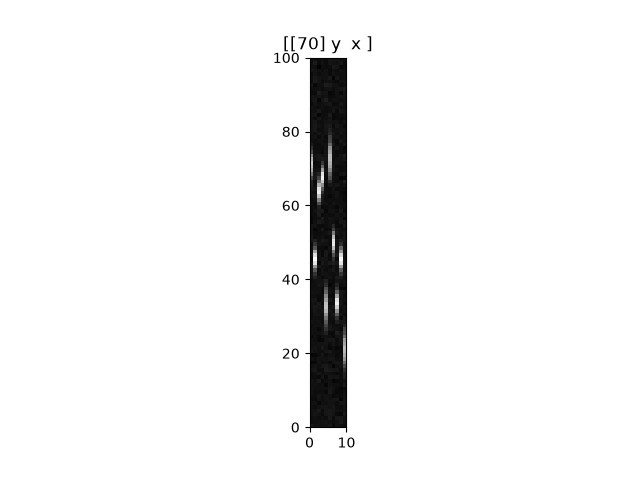

In [6]:
spl.ImagePlot(time_resolved_data.cpu().detach().numpy())

In [9]:
# Assuming your external rasterization and strategy modules are imported:
# from gsplat import project_gaussians_2d, project_gaussians_2d_scale_rot, rasterize_gaussians_sum

class Config:
    prune_opa: float = 0.05
    grow_grad2d: float = 0.02
    grow_scale3d: float = 0.01
    prune_scale3d: float = 0.1
    refine_start_iter: int = 500
    refine_stop_iter: int = 15_000
    reset_every: int = 3000
    refine_every: int = 100
    absgrad: bool = False
    revised_opacity: bool = False
    key_for_gradient = "gradient_2dgs"

class GaussianImage(nn.Module):
    def __init__(self, loss_type="L2", representation='Cholesky', **kwargs):
        super().__init__()
        self.loss_type = loss_type
        self.init_num_points = kwargs["num_points"]
        
        # H represents the spatial height (time_and_y)
        self.H, self.W = kwargs["H"], kwargs["W"]
        self.num_acquisitions = kwargs["num_acquisitions"]
        
        # Total chronological timepoints across all sequential acquisitions
        self.timepoints = self.H * self.num_acquisitions 
        self.representation = representation

        self.MINIBATCH = 20  
        self.BLOCK_W, self.BLOCK_H = kwargs["BLOCK_W"], kwargs["BLOCK_H"]
        self.tile_bounds = (
            (self.W + self.BLOCK_W - 1) // self.BLOCK_W,
            (self.H + self.BLOCK_H - 1) // self.BLOCK_H,
            1,
        )
        self.device = kwargs["device"]
        
        self.strategy = defaultstrategy.Strategy2DWithMotion(verbose=True)
        self.strategy_state = self.strategy.initialize_state()

        from scipy.stats import qmc
        sampler = qmc.Sobol(d=2, scramble=True)
        points_unit_domain = sampler.random(n=self.init_num_points)
        points_scaled = -1 + points_unit_domain * 2
        self._xyz = nn.Parameter(torch.from_numpy(points_scaled).float().to(self.device))

        # Motion tracking vectors expanded to span the full continuous sequential timeline
        self._motionvecs = nn.Parameter(torch.zeros(self.init_num_points, 2, self.timepoints))
        
        if self.representation.lower() == 'cholesky':
            self._cholesky = nn.Parameter(torch.rand(self.init_num_points, 3))
            self._choleskytime = nn.Parameter(torch.zeros(self.init_num_points, 3, self.timepoints))
        else:
            self._rotation = nn.Parameter(torch.rand(self.init_num_points, 1))
            self._scaling = nn.Parameter(torch.rand(self.init_num_points, 2))
            self.rotation_activation = torch.sigmoid
            
        self._opacity = nn.Parameter(torch.ones((self.init_num_points,)))
        self._features_dc = nn.Parameter(torch.zeros(self.init_num_points, 1)) 
        
        self.background = torch.zeros(1, device=self.device)
        self.opacity_activation = torch.sigmoid
        self.rgb_activation = torch.sigmoid
        
        self.register_buffer('bound', torch.tensor([0.5, 0.5]).view(1, 2))
        self.register_buffer('cholesky_bound', torch.tensor([0.5, 0, 0.5]).view(1, 3))

        if kwargs["opt_type"] == "adam":
            self.optimizer = torch.optim.Adam(self.parameters(), lr=kwargs["lr"])
        else:
            self.optimizer = Lion(self.parameters(), lr=kwargs["lr"])
            
        self.scheduler = torch.optim.lr_scheduler.StepLR(self.optimizer, step_size=1500, gamma=0.6)

    def get_xyz(self, t, motion=True):
        if motion:
            return torch.tanh(self._xyz + self._motionvecs[..., t].squeeze())
        else:
            return torch.tanh(self._xyz)
    
    @property
    def get_features(self):
        return self.rgb_activation(self._features_dc)
    
    def get_opacity(self, t, motion=True):
        return self.opacity_activation(self._opacity)

    def get_cholesky_elements(self, t, motion=True):
        if motion:
            return self._cholesky + self._choleskytime[..., t].squeeze() + self.cholesky_bound
        else:
            return self._cholesky + self.cholesky_bound
    
    def get_scaling(self, t):
        return torch.abs(self._scaling + self.bound)
    
    def get_rotation(self, t):
        return self.rotation_activation(self._rotation) * 2 * math.pi
    
    def forward(self, t, motion=True):
        if self.representation.lower() == 'cholesky':
            self.xys, depths, self.radii, conics, num_tiles_hit = project_gaussians_2d(
                self.get_xyz(t, motion=motion), 
                self.get_cholesky_elements(t, motion=motion), 
                self.H, self.W, self.tile_bounds
            )
        else:
            self.xys, depths, self.radii, conics, num_tiles_hit = project_gaussians_2d_scale_rot(
                self.get_xyz(t, motion=motion), 
                self.get_scaling(t), 
                self.get_rotation(t), 
                self.H, self.W, self.tile_bounds
            )
            
        out_img = rasterize_gaussians_sum(
            self.xys, depths, self.radii, conics, num_tiles_hit,
            self.get_features, 
            self.get_opacity(t, motion=motion).squeeze().unsqueeze(-1), 
            self.H, self.W, self.BLOCK_H, self.BLOCK_W, 
            background=self.background, return_alpha=False
        )
        
        return {"render": out_img.squeeze(-1), "points": self.get_xyz(t, motion=motion)}

    def train_iter(self, iter, target_slices, generate_image=False, generate_image_path=None):
        """
        Args:
            target_slices (torch.Tensor): Tensor of shape (time_and_y, x, acquisition)
        """
        mses, psnrs = 0.0, 0.0
        loss = 0.0

        # Randomly sample a combination of space-time rows and acquisition blocks
        sampled_y = torch.randint(low=0, high=self.H, size=(self.MINIBATCH,))
        sampled_acq = torch.randint(low=0, high=self.num_acquisitions, size=(self.MINIBATCH,))

        for idx in range(self.MINIBATCH):
            y_idx = sampled_y[idx].item()
            acq_idx = sampled_acq[idx].item()
            
            # Map sequential coordinates to absolute global timeline index
            t_abs = (acq_idx * self.H) + y_idx
            
            # Render the canvas matching the precise absolute chronological moment
            render_pkg = self.forward(t_abs, motion=True)
            rendered_image = render_pkg["render"]  # Shape: (H, W)
            
            # Extract row from the matching 2D frame space
            rendered_slice = rendered_image[y_idx, :]
            target_slice = target_slices[y_idx, :, acq_idx]
            
            if idx == 0 and (iter - 1) % 100 == 0 and generate_image and generate_image_path is not None:
                self.save_gaussian_visualizations(render_pkg, generate_image_path, iter, y_idx, acq_idx)
            
            if self.loss_type == "L1":
                loss_frame = torch.abs(rendered_slice - target_slice).mean()
            else:
                loss_frame = torch.mean((rendered_slice - target_slice) ** 2)
                
            loss += loss_frame / self.MINIBATCH

            with torch.no_grad():
                mse_val = torch.mean((rendered_slice - target_slice) ** 2)
                mses += mse_val / self.MINIBATCH
                psnr_val = 10 * math.log10(1.0 / (mse_val.item() + 1e-10))
                psnrs += psnr_val / self.MINIBATCH

        # Sequential smoothness constraints applied continuously along the global time axis
        reg_dvfrank = torch.linalg.norm(einops.rearrange(torch.tanh(self._motionvecs), 'space dim time -> (space dim) time'), "nuc")
        reg_tv_dvf = torch.linalg.vector_norm(torch.diff(torch.tanh(self._motionvecs), dim=-1), ord=1)
        reg_tv_cholesky = torch.linalg.vector_norm(torch.diff(self._choleskytime, dim=-1), ord=1)

        total_loss = loss #+ 0.001 * reg_dvfrank + 0.001 * reg_tv_dvf + 0.001 * reg_tv_cholesky
        total_loss.backward()
        
        info = {'height': self.H, 'width': self.W}
        
        if self.representation.lower() == 'cholesky':
            params_dict = {
                '_xyz': self._xyz, '_motionvecs': self._motionvecs,
                '_cholesky': self._cholesky, '_choleskytime': self._choleskytime, 
                '_opacity': self._opacity, '_features_dc': self._features_dc,
                'choleskybound': self.cholesky_bound
            }
        else:
            params_dict = {
                '_xyz': self._xyz, '_motionvecs': self._motionvecs,
                '_scaling': self._scaling, '_rotation': self._rotation,
                '_opacity': self._opacity, '_features_dc': self._features_dc
            }

#         self.strategy.step_post_backward(params_dict, self.optimizer, self.strategy_state, iter, info)
        
        self._xyz = params_dict["_xyz"]
        if self.representation.lower() == 'cholesky':
            self._cholesky = params_dict["_cholesky"]
            self._choleskytime = params_dict['_choleskytime']
        else:
            self._scaling = params_dict['_scaling']
            self._rotation = params_dict['_rotation']

        self._features_dc = params_dict["_features_dc"]
        self._opacity = params_dict["_opacity"]
        self._motionvecs = params_dict['_motionvecs']
        
        self.optimizer.step()
        self.optimizer.zero_grad(set_to_none=True)
        self.scheduler.step()
        
        return mses, psnrs

    def save_gaussian_visualizations(self, dic, base_storage_folder, iteration, y_idx, acq_idx):
        alpha_dir = os.path.join(base_storage_folder, "output_fig", "alpha")
        os.makedirs(alpha_dir, exist_ok=True)
        
        out_img = dic['render'].detach().abs()
        norm_img = 255 * (out_img / torch.quantile(out_img, 0.95).clamp(min=1e-5))
        norm_img = norm_img.clamp(0, 255).cpu().numpy().astype(np.uint8)

        my_image_alpha = Image.fromarray(norm_img).convert('RGB')
        draw_alpha = ImageDraw.Draw(my_image_alpha)
        
        # Red line highlights spatial scan location on the underlying 2D image coordinate
        draw_alpha.line([(0, y_idx), (self.W, y_idx)], fill=(255, 0, 0), width=1)
        
        text_str = f"Iter: {iteration - 1} | Acq: {acq_idx} | Row: {y_idx}"
        draw_alpha.text((10, 10), text_str, fill=(255, 255, 255), font_size=12)
        my_image_alpha.save(os.path.join(alpha_dir, f'{iteration-1}.png'))
        
        
class MotionTrainer2d:
    """Trains shared dynamic 2D Gaussians across a continuous sequence of 1D line-scans."""
    def __init__(
        self,
        target_slices: torch.Tensor,  # Shape: (time_and_y, x, acquisition)
        num_points: int = 2500,
        model_name: str = "GaussianImage_Cholesky",
        iterations: int = 5000,
        lr: float = 1e-3,
        model_path = None,
        args = None,
    ):
        self.device = torch.device("cuda:0")
        self.target_slices = target_slices.to(self.device)
        
        self.H = self.target_slices.shape[0]               # Spatial height (time_and_y)
        self.W = self.target_slices.shape[1]               # Spatial width (x)
        self.num_acquisitions = self.target_slices.shape[2] # Sequential epochs

        self.num_points = num_points
        BLOCK_H, BLOCK_W = 16, 16
        self.iterations = iterations
        
        self.gaussian_model = GaussianImage(
            loss_type="L2", 
            representation='cholesky',
            opt_type="adam", 
            num_points=self.num_points, 
            num_acquisitions=self.num_acquisitions,
            H=self.H, W=self.W, 
            BLOCK_H=BLOCK_H, BLOCK_W=BLOCK_W, 
            device=self.device, lr=lr, quantize=False
        ).to(self.device)
        
    def train(self, generate_image=False, generate_image_path=None):     
        psnr_list, iter_list = [], []
        progress_bar = tqdm(range(1, self.iterations+1), desc="Sequential Line Reconstruction")
        self.gaussian_model.train()
        
        for iter in range(1, self.iterations+1):
            loss, psnr = self.gaussian_model.train_iter(
                iter, 
                target_slices=self.target_slices,
                generate_image=generate_image, 
                generate_image_path=generate_image_path
            )
            psnr_list.append(psnr)
            iter_list.append(iter)
            
            with torch.no_grad():
                if iter % 10 == 0:
                    progress_bar.set_postfix({
                        "Loss": f"{loss.item():.{7}f}", 
                        "PSNR": f"{psnr:.{4}f}"
                    })
                    progress_bar.update(10)
                    
        progress_bar.close()

    def get_images(self):
        """Returns the complete sequence video across all sequential acquisitions."""
        self.gaussian_model.eval()
        imgs = []
        total_timepoints = self.H * self.num_acquisitions
        with torch.no_grad():
            for t in range(total_timepoints):
                out = self.gaussian_model(t, motion=True)['render']
                imgs.append(out)
                
        return torch.stack(imgs)

In [10]:
model = MotionTrainer2d(target_slices=time_resolved_data)
model.train()

/tmp/ipykernel_1063669/862824132.py:45: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  points_unit_domain = sampler.random(n=self.init_num_points)


Sequential Line Reconstruction:   0%|          | 0/5000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [11]:
spl.ImagePlot(ground_truth_data.cpu().detach().numpy())

NameError: name 'ground_truth_data' is not defined

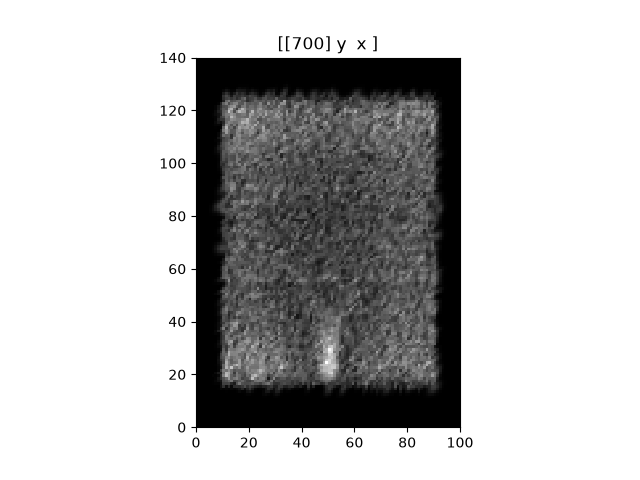

In [12]:
spl.ImagePlot(model.get_images().cpu().detach().numpy())

In [ ]:
print(model.gaussian_model.noise_params)